<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Neutrino002.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

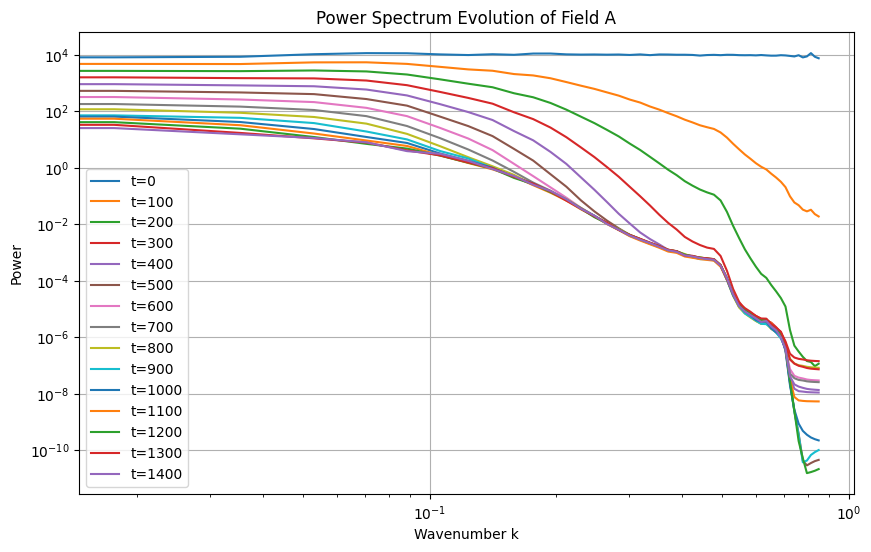

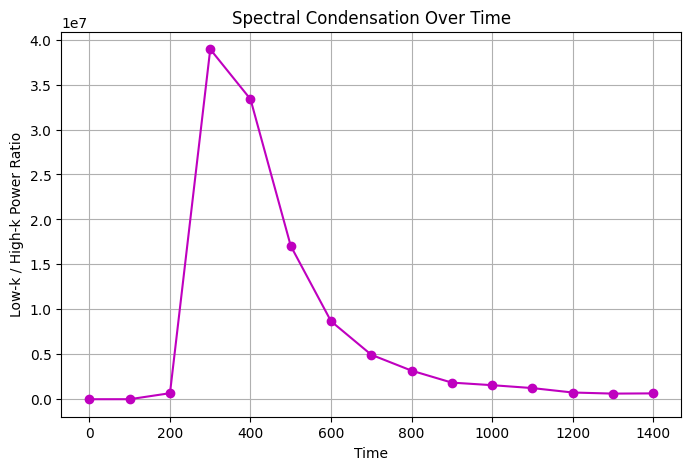

In [1]:
# 🧮 Step 1: Imports
import numpy as np
from scipy.fft import fftn, fftfreq
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

# 📐 Step 2: Parameters (Goldilocks blend)
nx, ny, nz = 50, 50, 50      # Grid size
t_steps = 1500               # Total time steps
dt = 0.01                    # Time step size

# HES constants
kappa = 0.25
delta = 0.015
gamma_0 = 0.5
sigma = 0.08  # Noise strength

# 🎲 Step 3: Initialization
A = np.random.rand(nx, ny, nz) - 0.5  # Initial field
power_evolution = []                 # Store spectra over time
low_k_ratio = []                     # Track spectral condensation

# ∇² operator
def laplacian_3d(A):
    lap = np.roll(A, 1, axis=0) + np.roll(A, -1, axis=0) + \
          np.roll(A, 1, axis=1) + np.roll(A, -1, axis=1) + \
          np.roll(A, 1, axis=2) + np.roll(A, -1, axis=2) - 6 * A
    return lap

# 📊 Step 4: Power Spectrum Function
def compute_power_spectrum(field):
    fft_A = fftn(field)
    power = np.abs(fft_A)**2

    kx = fftfreq(nx)
    ky = fftfreq(ny)
    kz = fftfreq(nz)
    kxx, kyy, kzz = np.meshgrid(kx, ky, kz, indexing='ij')
    k = np.sqrt(kxx**2 + kyy**2 + kzz**2)

    k_bins = np.linspace(0, np.max(k), 50)
    power_radial = np.zeros(len(k_bins) - 1)
    counts = np.zeros(len(k_bins) - 1)

    for i in range(len(k_bins) - 1):
        mask = (k >= k_bins[i]) & (k < k_bins[i+1])
        power_radial[i] = np.sum(power[mask])
        counts[i] = np.sum(mask)

    power_radial /= np.maximum(counts, 1)
    return k_bins[:-1], power_radial, k

# 🔁 Step 5: Simulation Loop
for t in range(t_steps):
    xi = gaussian_filter(np.random.normal(0, sigma, A.shape), sigma=1.5)  # Structured noise
    lap_A = gamma_0 * laplacian_3d(A)
    dA = -kappa * A + delta * A**2 + lap_A + xi
    A += dt * dA

    if t % 100 == 0:
        k_vals, power_radial, k_grid = compute_power_spectrum(A)
        power_evolution.append(power_radial)

        # Spectral condensation tracker
        low_k = np.mean(power_radial[k_vals < 0.2])
        high_k = np.mean(power_radial[k_vals > 0.5])
        ratio = low_k / high_k if high_k > 0 else 0
        low_k_ratio.append(ratio)

# 📈 Step 6: Plot Power Spectrum Evolution
plt.figure(figsize=(10, 6))
for i, p in enumerate(power_evolution):
    plt.loglog(k_vals, p, label=f't={i*100}')
plt.xlabel('Wavenumber k')
plt.ylabel('Power')
plt.title('Power Spectrum Evolution of Field A')
plt.legend()
plt.grid(True)
plt.show()

# 📉 Step 7: Plot Spectral Condensation Tracker
plt.figure(figsize=(8, 5))
plt.plot(range(0, t_steps, 100), low_k_ratio, 'm-o')
plt.xlabel('Time')
plt.ylabel('Low-k / High-k Power Ratio')
plt.title('Spectral Condensation Over Time')
plt.grid(True)
plt.show()
